In [4]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
# import pymaster as nmt
import pysm3
import pysm3.units as u
# uses the CAMB cosmology which produced the cls
import camb
from cosmology import Cosmology
import glass
import glass.ext.camb


Simulate Synchrotron radiation using PYSM

In [5]:
def simulate_planck_maps(nside, freqs):
    """
    Simulate foreground emission and noise at different Planck frequencies.
    
    Parameters:
    nside (int): Healpix resolution parameter.
    
    Returns:
    tuple: Numpy arrays of simulated maps for synchrotron and free-free
    """    
    sens = np.array([150.,  162.,  210.,  77.4,  33.,  46.8, 154,  42.,  5016.])
    
    # Initialize PySM sky models for different foregrounds and CMB
    sky_s = pysm3.Sky(nside, preset_strings=["s1"])
    sky_f = pysm3.Sky(nside, preset_strings=["f1"])
    
    # Initialize storage for maps
    sync= []
    ff=[]
    # noise=[]
    for nf, freq in enumerate(freqs):
        # Generate noise
        # noise_pl = np.random.normal(size=(12 * nside**2)) * sens[nf] / hp.nside2resol(nside, True)
        # noise.append(noise_pl)
        
        # Convert emissions to uK_CMB
        conversion = u.K_RJ.to(u.K_CMB, equivalencies=u.cmb_equivalencies(freq * u.MHz))
        
        sync.append(sky_s.get_emission(freq * u.MHz)[0] * conversion)
        ff.append(sky_f.get_emission(freq * u.GHz)[0] * conversion)
        
    
    # Convert lists to numpy arrays (N_freq, N_pixels)
    return  np.array(sync), np.array(ff)


In [6]:
nside=256
freqs=np.arange(1042,1183,step=1) #instead of steps of1MHz use 10
nfreqs=len(freqs)
lmax=3*nside -1

# creating a numpy random number generator for sampling
rng = np.random.default_rng(seed=42)

# cosmology for the simulation
h = 0.7
Oc = 0.25
Ob = 0.05

# set up CAMB parameters for matter angular power spectrum
pars = camb.set_params(
    H0=100 * h,
    omch2=Oc * h**2,
    ombh2=Ob * h**2,
    NonLinear=camb.model.NonLinear_both,
)

In [17]:
sync,ff=simulate_planck_maps(nside, freqs)
print(sync.shape)

(141, 786432)


In [18]:
np.save("/datadec/cppm/shoaib/SMICA_Paper/data/sync_maps_mK.npy", sync*1e-3)
np.save("/datadec/cppm/shoaib/SMICA_Paper/data/ff_maps_mK.npy", ff*1e-3)

In [19]:
cl_sync=np.zeros((nfreqs, lmax+1))
cl_ff=np.zeros((nfreqs, lmax+1))
# calculate the angular power spectrum for synchrotron and free-free
for i in range (nfreqs):  
    print ("processing spectra %d" % i) 
    cl_sync[i,:]= hp.anafast(sync[i,:]*1e-3, lmax=lmax)
    cl_ff[i,:]= hp.anafast(ff[i,:]*1e-3, lmax=lmax)

processing spectra 0
processing spectra 1
processing spectra 2
processing spectra 3
processing spectra 4
processing spectra 5
processing spectra 6
processing spectra 7
processing spectra 8
processing spectra 9
processing spectra 10
processing spectra 11
processing spectra 12
processing spectra 13
processing spectra 14
processing spectra 15
processing spectra 16
processing spectra 17
processing spectra 18
processing spectra 19
processing spectra 20
processing spectra 21
processing spectra 22
processing spectra 23
processing spectra 24
processing spectra 25
processing spectra 26
processing spectra 27
processing spectra 28
processing spectra 29
processing spectra 30
processing spectra 31
processing spectra 32
processing spectra 33
processing spectra 34
processing spectra 35
processing spectra 36
processing spectra 37
processing spectra 38
processing spectra 39
processing spectra 40
processing spectra 41
processing spectra 42
processing spectra 43
processing spectra 44
processing spectra 4

In [13]:
print(cl_sync.shape)

(141, 768)


In [147]:
np.save("cl_sync.npy", cl_sync)
np.save("cl_ff.npy", cl_ff)

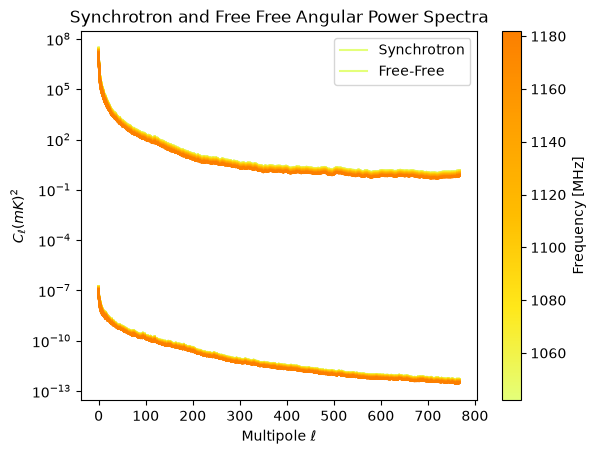

In [21]:
# Normalize for colormap
cmap = plt.get_cmap('Wistia')
norm = plt.Normalize(freqs.min(), freqs.max())
cmap1 = plt.get_cmap('viridis')
norm1 = plt.Normalize(freqs.min(), freqs.max())

fig, ax = plt.subplots()

for i, f in enumerate(freqs):
    
    ax.plot(cl_sync[i,:], color=cmap(norm(f)), label='Synchrotron' if i == 0 else None)

    ax.plot(cl_ff[i,:], color=cmap(norm(f)), label='Free-Free' if i == 0 else None)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy for older matplotlib versions
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Frequency [MHz]')

ax.set_yscale('log')
ax.set_xlabel('Multipole ℓ')
ax.set_ylabel(r'$C_\ell (mK)^2$')
ax.set_title('Synchrotron and Free Free Angular Power Spectra')
plt.legend()
plt.show()

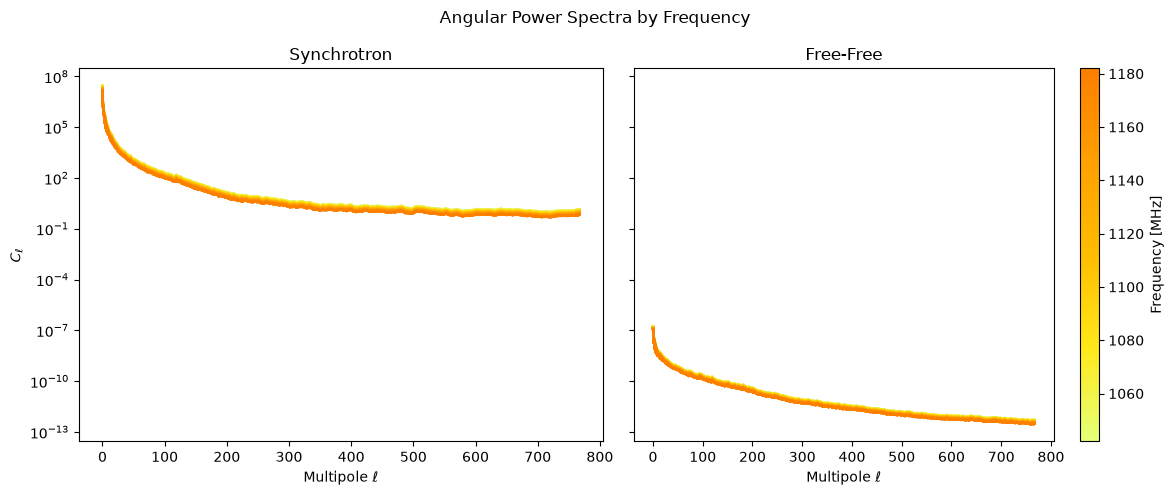

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Synchrotron (left)
for i, f in enumerate(freqs):
    axs[0].plot(cl_sync[i, :], color=cmap(norm(f)))
axs[0].set_title('Synchrotron')
axs[0].set_xlabel('Multipole ℓ')
axs[0].set_ylabel(r'$C_\ell$')
axs[0].set_yscale('log')

# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm1.set_array([])
# fig.colorbar(sm1, ax=axs[0], label='Frequency [MHz]')

# Free-Free (right)
for i, f in enumerate(freqs):
    axs[1].plot(cl_ff[i, :], color=cmap(norm(f)))
axs[1].set_title('Free-Free')
axs[1].set_xlabel('Multipole ℓ')
axs[1].set_yscale('log')

sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm2.set_array([])
fig.colorbar(sm2, ax=axs[1], label='Frequency [MHz]')

plt.suptitle('Angular Power Spectra by Frequency')
plt.tight_layout()
plt.show()


# FIN

The rest-frame frequency of the 21cm line is: $ν_{21}=1420.40575$ MHz

Because of cosmic expansion, light emitted at some earlier time gets redshifted, so the observed frequency is lower than the emitted frequency:
$$1 + z = \frac{\nu_{21}}{\nu_{\text{obs}}}$$

In [9]:
z_f= (1420/1042)-1
z_i= (1420/1183)-1
# set up the redshift range
# z = np.linspace(z_i, z_f, nfreqs)
print(z_i, z_f)

0.20033812341504653 0.36276391554702503


In [10]:
print(nfreqs)

141
